# ML Mini Project — Image Super-Resolution with SRCNN

### Team Members
- **Deeptanshu Kumar** — PES1UG24AM357
- **Krish Mathur** — PES1UG24AM914

### Project Overview
This project studies **single-image super-resolution (SISR)** using convolutional neural networks. We begin with conventional interpolation methods and the original **SRCNN** as reference methods, then investigate progressively deeper and residual architectures.

The notebook follows a controlled workflow: the same dataset and degradation process are used throughout, model variants are trained under a common evaluation pipeline, and performance is measured using **MSE** and **PSNR**.

### Experimental Roadmap
**Interpolation baselines → SRCNN → Deep SRCNN → Stabilized Deep SRCNN → Deep Residual SRCNN → Data-scale experiment**

The later experiments build on the earlier results rather than changing several factors at once, making it easier to understand what each extension contributes.

- **Deep SRCNN:** Extends the original SRCNN with additional convolutional layers.
- **Stabilized Deep SRCNN:** Uses a reduced learning rate and gradient clipping to improve training stability.
- **Deep Residual SRCNN:** Introduces a global residual connection, enabling the network to learn the reconstruction residual relative to the input.


### Extensions over the Base Paper

- **Deeper Architecture:** Extended the original 3-layer SRCNN to a deeper five-convolution **Deep SRCNN** architecture.
- **Training Stabilization:** Introduced a stabilized training configuration using a lower learning rate (`3e-4`) and gradient clipping.
- **Residual Learning:** Developed a **Deep Residual SRCNN** by adding a global residual connection to the deeper SRCNN backbone.
- **Larger-Scale Training:** Extended the base paper's **60-image training setup** to an **800-image training set**.
- **Data-Scaling Study:** Added a controlled **60 vs. 800 training-image comparison** using the same fixed 100-image test set.

## 1. Setup and imports

We first load the libraries and define the settings shared across the experiments. A fixed random seed is used so that the dataset split and training setup remain reproducible.

In [1]:
# Core libraries
import os
import math
import random
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from torchvision.transforms.functional import to_tensor, to_pil_image

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Main project settings
IMAGE_SIZE = 224
LR_SIZE = 112
CROP_SIZE = 800

BATCH_SIZE = 4
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3

print(f"\nDevice: {device}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4

Device: cuda
Batch size: 4
Epochs: 50
Learning rate: 0.001


## 2. Load the 100-image DIV2K-derived dataset

We use a fixed 100-image subset for the initial study. Keeping the same images throughout the baseline and model experiments makes the comparisons consistent.

In [2]:
# The original notebook downloaded this Parquet file with resume support.
DATA_URL = (
    "https://huggingface.co/datasets/huaweilin/VTBench/"
    "resolve/main/DIV2K/test-00000-of-00001.parquet"
)
DATA_PATH = "/content/div2k.parquet"

# Install only what is needed if running in a fresh Colab session.
!pip -q install pyarrow pandas pillow matplotlib

# Download if the file is not already present.
if not os.path.exists(DATA_PATH):
    !wget -c --tries=20 --timeout=30 "$DATA_URL" -O "$DATA_PATH"

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

--2026-10-03 07:42:45--  https://huggingface.co/datasets/huaweilin/VTBench/resolve/main/DIV2K/test-00000-of-00001.parquet
Resolving huggingface.co (huggingface.co)... 99.86.101.36, 99.86.101.56, 99.86.101.39, ...
Connecting to huggingface.co (huggingface.co)|99.86.101.36|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/67ff2e063b42083b3725b8f6/79eec7ce91c8991d497f2e969440933655a8dc95fe64f51b685954b495b7545a?user_id=public&X-Xet-Cas-Uid=public&xip=F92SWfyclXc&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27test-00000-of-00001.parquet%3B+filename%3D%22test-00000-of-00001.parquet%22%3B&Expires=1791016965&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5nY3AuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjdmZjJlMDYzYjQyMDgzYjM3MjViOGY2Lzc5ZWVjN2NlOTFjODk5MWQ0OTdmMmU5Njk0NDA5MzM2NTVhOGRjOTVmZTY0ZjUxYjY4NTk1NGI0OTViNzU0NWFcXD91c2VyX2lkPXB1YmxpYyZYLVhldC1DYXMtVWlkPXB1YmxpYyZ4aXA9RjkyU1dmeWNsWGMmcmVzcG9uc2UtY29udGVud

Example image size: (2040, 1356)


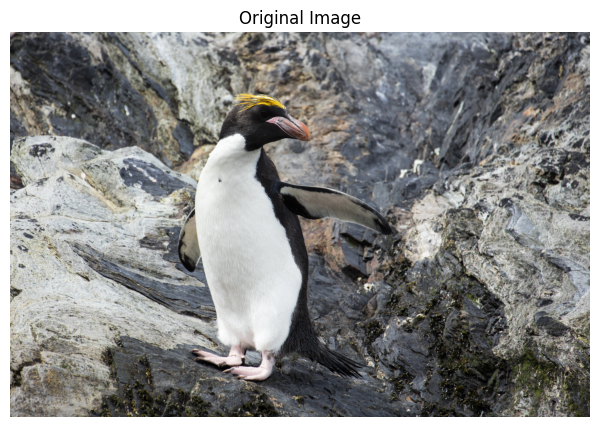

In [3]:
def get_image(row):
    """Decode one PNG stored as bytes and return an RGB PIL image."""
    image_bytes = row["image"]["bytes"]
    return Image.open(BytesIO(image_bytes)).convert("RGB")


img = get_image(df.iloc[0])

print("Example image size:", img.size)

plt.figure(figsize=(8, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Original Image")
plt.show()

## 3. Preprocessing: create HR targets and LR inputs

Each image is converted into a common 224×224 high-resolution target and a degraded 224×224 input. The degradation is created by downsampling to 112×112 and then upsampling back to the model input size.

In [4]:
def preprocess_image(img):
    """
    Match the preprocessing used in the original notebook:

    1. Center crop to 800x800
    2. Resize to 224x224 -> HR target
    3. Downsample to 112x112 -> degraded image
    4. Upsample to 224x224 -> model input
    """
    img = img.convert("RGB")

    w, h = img.size
    left = max((w - CROP_SIZE) // 2, 0)
    top = max((h - CROP_SIZE) // 2, 0)

    hr = img.crop(
        (left, top, left + CROP_SIZE, top + CROP_SIZE)
    )

    hr = hr.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BICUBIC
    )

    lr_small = hr.resize(
        (LR_SIZE, LR_SIZE),
        Image.Resampling.BILINEAR
    )

    lr = lr_small.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR
    )

    return hr, lr_small, lr

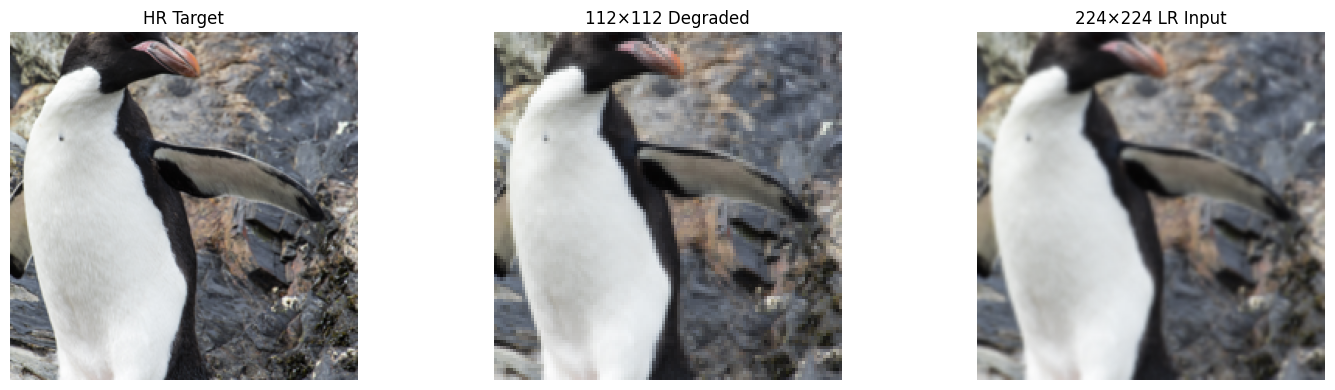

In [5]:
# Quick visual sanity check
hr, lr_small, lr = preprocess_image(img)

plt.figure(figsize=(15, 4))

for i, (image, title) in enumerate([
    (hr, "HR Target"),
    (lr_small, "112×112 Degraded"),
    (lr, "224×224 LR Input")
]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Train / validation / test split

The 100 images are randomly split into **60 training, 20 validation, and 20 test images**. The test set is kept separate so it is only used for final evaluation.

In [6]:
indices = np.arange(len(df))

rng = np.random.default_rng(SEED)
rng.shuffle(indices)

train_idx = indices[:60]
val_idx = indices[60:80]
test_idx = indices[80:100]

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))

Train: 60
Validation: 20
Test: 20


## 5. Faster data pipeline — preprocess once, train many times

Because the dataset is small, it is more efficient to perform the image decoding and resizing once and keep the resulting tensors in memory. This removes repeated preprocessing from every training epoch without changing the data seen by the models.

In [7]:
# IMPORTANT SPEEDUP:
# The original notebook decoded and resized PIL images inside __getitem__()
# for every epoch. We now do that expensive CPU work exactly once.

all_lr = []
all_hr = []
all_lr_small = []

for i in range(len(df)):
    img_i = get_image(df.iloc[i])
    hr_i, lr_small_i, lr_i = preprocess_image(img_i)

    all_hr.append(to_tensor(hr_i))
    all_lr_small.append(to_tensor(lr_small_i))
    all_lr.append(to_tensor(lr_i))

all_hr = torch.stack(all_hr)
all_lr_small = torch.stack(all_lr_small)
all_lr = torch.stack(all_lr)

print("HR:", all_hr.shape)
print("LR small:", all_lr_small.shape)
print("LR input:", all_lr.shape)

HR: torch.Size([100, 3, 224, 224])
LR small: torch.Size([100, 3, 112, 112])
LR input: torch.Size([100, 3, 224, 224])


In [8]:
# Split the already-preprocessed tensors.
train_dataset = TensorDataset(
    all_lr[train_idx],
    all_hr[train_idx]
)

val_dataset = TensorDataset(
    all_lr[val_idx],
    all_hr[val_idx]
)

test_dataset = TensorDataset(
    all_lr[test_idx],
    all_hr[test_idx]
)

# In-memory tensors + batch size 16 are much more efficient for this small dataset.
# num_workers=0 is intentional: there is no image decoding left for workers to do.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

lr_batch, hr_batch = next(iter(train_loader))

print("LR batch shape:", lr_batch.shape)
print("HR batch shape:", hr_batch.shape)
print("LR range:", lr_batch.min().item(), "to", lr_batch.max().item())
print("HR range:", hr_batch.min().item(), "to", hr_batch.max().item())

LR batch shape: torch.Size([4, 3, 224, 224])
HR batch shape: torch.Size([4, 3, 224, 224])
LR range: 0.003921568859368563 to 0.9725490212440491
HR range: 0.0 to 1.0


## 6. Metrics and reusable training/evaluation helpers

The same training and evaluation functions are reused for the neural models. MSE is used as the training objective, while PSNR is derived from the global test MSE for a consistent comparison.

In [9]:
def calculate_psnr_from_mse(mse):
    """PSNR for tensors normalized to the [0, 1] range."""
    if mse <= 0:
        return float("inf")
    return 10 * math.log10(1.0 / mse)


def evaluate_model(model, loader):
    """
    Evaluate using global pixel-level MSE, then derive one PSNR from it.
    This keeps the MSE and PSNR calculation consistent across models.
    """
    model.eval()

    total_squared_error = 0.0
    total_pixels = 0

    with torch.no_grad():
        for lr, hr in loader:
            lr = lr.to(device, non_blocking=True)
            hr = hr.to(device, non_blocking=True)

            output = model(lr).clamp(0, 1)

            total_squared_error += torch.sum(
                (output - hr) ** 2
            ).item()

            total_pixels += hr.numel()

    mse = total_squared_error / total_pixels
    psnr = calculate_psnr_from_mse(mse)

    return mse, psnr

In [10]:

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    grad_clip_norm=None
):
    """
    Train a model and retain the checkpoint with the best validation PSNR.

    grad_clip_norm:
        If set (e.g. 1.0), clip the total gradient norm after backpropagation.
        This is used for the deeper models to make optimization more stable.
    """

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    train_losses = []
    val_losses = []
    val_psnrs = []

    best_val_psnr = -float("inf")
    best_state = None

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------
        model.train()
        running_loss = 0.0

        for lr_batch, hr_batch in train_loader:
            lr_batch = lr_batch.to(device, non_blocking=True)
            hr_batch = hr_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            output = model(lr_batch)
            loss = criterion(output, hr_batch)

            loss.backward()

            # Optional stabilization for deeper architectures.
            if grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=grad_clip_norm
                )

            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        # -------------------------
        # Validation
        # -------------------------
        model.eval()

        total_squared_error = 0.0
        total_val_pixels = 0

        with torch.no_grad():
            for lr_batch, hr_batch in val_loader:
                lr_batch = lr_batch.to(device, non_blocking=True)
                hr_batch = hr_batch.to(device, non_blocking=True)

                output = model(lr_batch).clamp(0, 1)

                total_squared_error += torch.sum(
                    (output - hr_batch) ** 2
                ).item()

                total_val_pixels += hr_batch.numel()

        val_mse = total_squared_error / total_val_pixels
        val_psnr = calculate_psnr_from_mse(val_mse)

        train_losses.append(train_loss)
        val_losses.append(val_mse)
        val_psnrs.append(val_psnr)

        if val_psnr > best_val_psnr:
            best_val_psnr = val_psnr
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val MSE: {val_mse:.6f} | "
            f"Val PSNR: {val_psnr:.2f} dB"
        )

    # Restore the best validation checkpoint.
    model.load_state_dict(best_state)
    model.to(device)

    history = {
        "train_loss": train_losses,
        "val_loss": val_losses,
        "val_psnr": val_psnrs,
        "best_val_psnr": best_val_psnr,
    }

    return history


## 7. Baseline SRCNN

We first implement the original three-convolution SRCNN architecture. This provides the main learned reference point before introducing deeper and residual variants.

In [11]:
class SRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Patch extraction
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=9,
            padding=4
        )

        # Non-linear mapping
        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=32,
            kernel_size=1
        )

        # Reconstruction
        self.conv3 = nn.Conv2d(
            in_channels=32,
            out_channels=3,
            kernel_size=5,
            padding=2
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.conv3(x)
        return x


srcnn = SRCNN().to(device)

print(srcnn)
print("Parameters:", sum(p.numel() for p in srcnn.parameters()))

SRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU()
)
Parameters: 20099


In [12]:
# Shape sanity check
sample_lr, _ = next(iter(train_loader))
sample_lr = sample_lr.to(device)

with torch.no_grad():
    sample_output = srcnn(sample_lr)

print("Input :", sample_lr.shape)
print("Output:", sample_output.shape)

Input : torch.Size([4, 3, 224, 224])
Output: torch.Size([4, 3, 224, 224])


In [13]:
# Train baseline SRCNN
srcnn_history = train_model(
    srcnn,
    train_loader,
    val_loader
)

Epoch 01/50 | Train Loss: 0.073925 | Val MSE: 0.028196 | Val PSNR: 15.50 dB
Epoch 02/50 | Train Loss: 0.022870 | Val MSE: 0.016121 | Val PSNR: 17.93 dB
Epoch 03/50 | Train Loss: 0.016567 | Val MSE: 0.013763 | Val PSNR: 18.61 dB
Epoch 04/50 | Train Loss: 0.013085 | Val MSE: 0.011748 | Val PSNR: 19.30 dB
Epoch 05/50 | Train Loss: 0.011526 | Val MSE: 0.010620 | Val PSNR: 19.74 dB
Epoch 06/50 | Train Loss: 0.009748 | Val MSE: 0.008832 | Val PSNR: 20.54 dB
Epoch 07/50 | Train Loss: 0.008237 | Val MSE: 0.007795 | Val PSNR: 21.08 dB
Epoch 08/50 | Train Loss: 0.007328 | Val MSE: 0.007330 | Val PSNR: 21.35 dB
Epoch 09/50 | Train Loss: 0.006816 | Val MSE: 0.006716 | Val PSNR: 21.73 dB
Epoch 10/50 | Train Loss: 0.006262 | Val MSE: 0.006479 | Val PSNR: 21.89 dB
Epoch 11/50 | Train Loss: 0.005996 | Val MSE: 0.006253 | Val PSNR: 22.04 dB
Epoch 12/50 | Train Loss: 0.005757 | Val MSE: 0.006017 | Val PSNR: 22.21 dB
Epoch 13/50 | Train Loss: 0.005682 | Val MSE: 0.005866 | Val PSNR: 22.32 dB
Epoch 14/50 

In [14]:
# Final test evaluation for baseline SRCNN
srcnn_test_mse, srcnn_test_psnr = evaluate_model(
    srcnn,
    test_loader
)

print(f"SRCNN Test MSE : {srcnn_test_mse:.6f}")
print(f"SRCNN Test PSNR: {srcnn_test_psnr:.2f} dB")

os.makedirs("/content/outputs", exist_ok=True)

torch.save(
    srcnn.state_dict(),
    "/content/outputs/srcnn_baseline.pth"
)

SRCNN Test MSE : 0.002848
SRCNN Test PSNR: 25.46 dB


### Baseline SRCNN result

This gives us the first learned benchmark on the held-out test set. We will now compare it against simpler interpolation methods before changing the network architecture.

## 8. Non-neural baselines

Nearest-neighbor, bilinear, and bicubic interpolation provide simple reference points that require no training. Comparing them with SRCNN shows whether the learned model is actually improving on standard upsampling.

In [15]:
def evaluate_interpolation(test_indices, method):
    """
    Use exactly the same HR targets and degradation process as the neural models.
    Only the final 112x112 -> 224x224 interpolation method changes.
    """

    total_squared_error = 0.0
    total_pixels = 0

    for pos, idx in enumerate(test_indices):

        pred_small = all_lr_small[idx]
        hr = all_hr[idx]

        pred_small_pil = to_pil_image(pred_small)

        if method == "nearest":
            resample = Image.Resampling.NEAREST
        elif method == "bilinear":
            resample = Image.Resampling.BILINEAR
        elif method == "bicubic":
            resample = Image.Resampling.BICUBIC
        else:
            raise ValueError("method must be nearest, bilinear, or bicubic")

        pred_pil = pred_small_pil.resize(
            (IMAGE_SIZE, IMAGE_SIZE),
            resample
        )

        pred = to_tensor(pred_pil)

        total_squared_error += torch.sum(
            (pred - hr) ** 2
        ).item()

        total_pixels += hr.numel()

    mse = total_squared_error / total_pixels
    psnr = calculate_psnr_from_mse(mse)

    return mse, psnr


baseline_results = {}

for method in ["nearest", "bilinear", "bicubic"]:
    mse, psnr = evaluate_interpolation(test_idx, method)

    baseline_results[method] = {
        "MSE": mse,
        "PSNR": psnr
    }

    print(
        f"{method.title():10s} | "
        f"MSE: {mse:.6f} | "
        f"PSNR: {psnr:.2f} dB"
    )

Nearest    | MSE: 0.003608 | PSNR: 24.43 dB
Bilinear   | MSE: 0.003663 | PSNR: 24.36 dB
Bicubic    | MSE: 0.002985 | PSNR: 25.25 dB


In [16]:
# Combine the results into one table.
results = pd.DataFrame([
    {
        "Method": "Nearest Neighbor",
        "Test MSE": baseline_results["nearest"]["MSE"],
        "Test PSNR": baseline_results["nearest"]["PSNR"]
    },
    {
        "Method": "Bilinear",
        "Test MSE": baseline_results["bilinear"]["MSE"],
        "Test PSNR": baseline_results["bilinear"]["PSNR"]
    },
    {
        "Method": "Bicubic",
        "Test MSE": baseline_results["bicubic"]["MSE"],
        "Test PSNR": baseline_results["bicubic"]["PSNR"]
    },
    {
        "Method": "SRCNN",
        "Test MSE": srcnn_test_mse,
        "Test PSNR": srcnn_test_psnr
    },
    {
        "Method": "Deep SRCNN",
        "Test MSE": None,
        "Test PSNR": None
    },
    {
        "Method": "U-Net",
        "Test MSE": None,
        "Test PSNR": None
    }
])

display(results)

,Method,Test MSE,Test PSNR
0,Nearest Neighbor,0.003608,24.427516
1,Bilinear,0.003663,24.361252
2,Bicubic,0.002985,25.250333
3,SRCNN,0.002848,25.455231
4,Deep SRCNN,NaN,NaN
5,U-Net,NaN,NaN


### What the baselines establish

The interpolation results give a clear reference range for the task. SRCNN can now be judged not just by its absolute PSNR, but by how much it improves over these non-neural alternatives.

## 9. SRCNN visual comparison

A visual comparison complements the numerical metrics by showing how the different interpolation methods and SRCNN reconstruct the same test image. This helps us see where learned reconstruction begins to recover sharper structure.

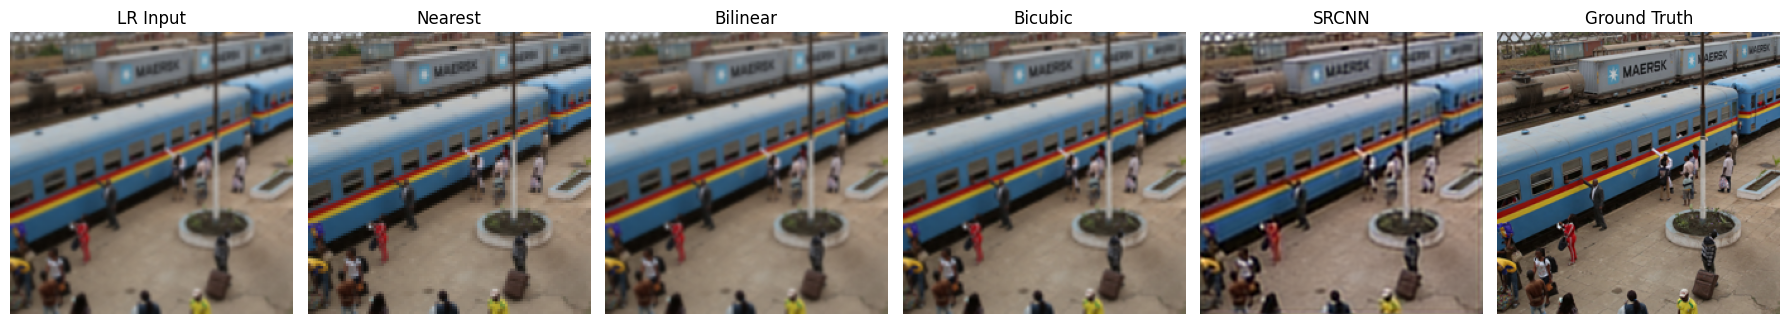

In [17]:
def get_srcnn_visual(idx, model):
    original = get_image(df.iloc[idx])
    hr, lr_small, lr = preprocess_image(original)

    nearest = lr_small.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.NEAREST
    )
    bilinear = lr_small.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BILINEAR
    )
    bicubic = lr_small.resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        Image.Resampling.BICUBIC
    )

    lr_tensor = to_tensor(lr).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(lr_tensor).clamp(0, 1)

    srcnn_image = to_pil_image(output.squeeze(0).cpu())

    return [
        lr,
        nearest,
        bilinear,
        bicubic,
        srcnn_image,
        hr
    ], [
        "LR Input",
        "Nearest",
        "Bilinear",
        "Bicubic",
        "SRCNN",
        "Ground Truth"
    ]


images, titles = get_srcnn_visual(test_idx[0], srcnn)

plt.figure(figsize=(18, 4))

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 6, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "/content/outputs/srcnn_visual_comparison.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

## 10. Deep SRCNN — controlled depth experiment

The next step is to increase the capacity of SRCNN by adding convolutional layers while keeping the overall reconstruction setup the same. The first run uses the baseline learning rate and is followed by a stabilized run to separate architectural effects from optimization issues.

For stabilization, we use **learning rate = 3e-4** and **gradient clipping with max norm = 1.0**. Everything else is kept the same so the effect of this training change can be interpreted cleanly.

In [18]:
class DeepSRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Original SRCNN feature extraction
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=64,
            kernel_size=9,
            padding=4
        )

        # Added nonlinear depth
        self.conv2 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        # Original SRCNN mapping + reconstruction
        self.conv4 = nn.Conv2d(
            in_channels=64,
            out_channels=32,
            kernel_size=1
        )

        self.conv5 = nn.Conv2d(
            in_channels=32,
            out_channels=3,
            kernel_size=5,
            padding=2
        )

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.relu(self.conv4(x))
        x = self.conv5(x)
        return x


deep_srcnn = DeepSRCNN().to(device)

baseline_params = sum(p.numel() for p in srcnn.parameters())
deep_params = sum(p.numel() for p in deep_srcnn.parameters())

print(deep_srcnn)
print(f"\nBaseline SRCNN parameters: {baseline_params:,}")
print(f"Deep SRCNN parameters:     {deep_params:,}")
print(f"Parameter increase:        {deep_params / baseline_params:.2f}x")

DeepSRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv5): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU()
)

Baseline SRCNN parameters: 20,099
Deep SRCNN parameters:     93,955
Parameter increase:        4.67x


In [19]:

# Stabilized Deep SRCNN
deep_srcnn = DeepSRCNN().to(device)

DEEP_LR = 3e-4
DEEP_GRAD_CLIP = 1.0

deep_history = train_model(
    deep_srcnn,
    train_loader,
    val_loader,
    lr=DEEP_LR,
    grad_clip_norm=DEEP_GRAD_CLIP
)


Epoch 01/50 | Train Loss: 0.135362 | Val MSE: 0.064204 | Val PSNR: 11.92 dB
Epoch 02/50 | Train Loss: 0.038185 | Val MSE: 0.021853 | Val PSNR: 16.60 dB
Epoch 03/50 | Train Loss: 0.023404 | Val MSE: 0.018151 | Val PSNR: 17.41 dB
Epoch 04/50 | Train Loss: 0.019949 | Val MSE: 0.015780 | Val PSNR: 18.02 dB
Epoch 05/50 | Train Loss: 0.017171 | Val MSE: 0.013211 | Val PSNR: 18.79 dB
Epoch 06/50 | Train Loss: 0.013428 | Val MSE: 0.011365 | Val PSNR: 19.44 dB
Epoch 07/50 | Train Loss: 0.010361 | Val MSE: 0.010947 | Val PSNR: 19.61 dB
Epoch 08/50 | Train Loss: 0.009466 | Val MSE: 0.008526 | Val PSNR: 20.69 dB
Epoch 09/50 | Train Loss: 0.008213 | Val MSE: 0.008193 | Val PSNR: 20.87 dB
Epoch 10/50 | Train Loss: 0.007621 | Val MSE: 0.007571 | Val PSNR: 21.21 dB
Epoch 11/50 | Train Loss: 0.007101 | Val MSE: 0.007357 | Val PSNR: 21.33 dB
Epoch 12/50 | Train Loss: 0.006760 | Val MSE: 0.006973 | Val PSNR: 21.57 dB
Epoch 13/50 | Train Loss: 0.006414 | Val MSE: 0.006906 | Val PSNR: 21.61 dB
Epoch 14/50 

In [20]:

# Evaluate stabilized Deep SRCNN
deep_test_mse, deep_test_psnr = evaluate_model(
    deep_srcnn,
    test_loader
)

print(f"Stabilized Deep SRCNN Test MSE : {deep_test_mse:.6f}")
print(f"Stabilized Deep SRCNN Test PSNR: {deep_test_psnr:.2f} dB")

torch.save(
    deep_srcnn.state_dict(),
    "/content/outputs/deep_srcnn_stabilized.pth"
)


Stabilized Deep SRCNN Test MSE : 0.002894
Stabilized Deep SRCNN Test PSNR: 25.38 dB


### Why the stabilized run matters

The deeper architecture does not automatically improve the result, so we treat training stability as a separate variable. This keeps the next comparison focused on whether the deeper model can learn effectively under a better-behaved optimization setup.

## 11. Compare SRCNN and stabilized Deep SRCNN

Here we place the deeper model next to the original SRCNN under the same test protocol. The earlier 25.40 dB Deep SRCNN result is retained as a reference for the uncontrolled run, while the stabilized result tells us whether better optimization changes the conclusion.

In [21]:

results.loc[results["Method"] == "Deep SRCNN", "Test MSE"] = deep_test_mse
results.loc[results["Method"] == "Deep SRCNN", "Test PSNR"] = deep_test_psnr

display(results)

print(
    f"Stabilized Deep SRCNN vs SRCNN: "
    f"{deep_test_psnr - srcnn_test_psnr:+.2f} dB"
)


,Method,Test MSE,Test PSNR
0,Nearest Neighbor,0.003608,24.427516
1,Bilinear,0.003663,24.361252
2,Bicubic,0.002985,25.250333
3,SRCNN,0.002848,25.455231
4,Deep SRCNN,0.002894,25.384356
5,U-Net,NaN,NaN


Stabilized Deep SRCNN vs SRCNN: -0.07 dB


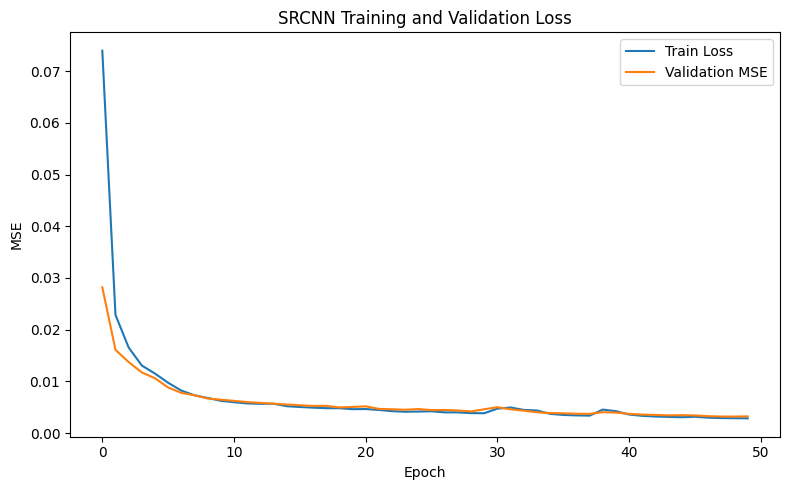

In [22]:

# Plot 1: Training and validation loss — SRCNN
plt.figure(figsize=(8, 5))
plt.plot(srcnn_history["train_loss"], label="Train Loss")
plt.plot(srcnn_history["val_loss"], label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SRCNN Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig(
    "/content/outputs/srcnn_loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


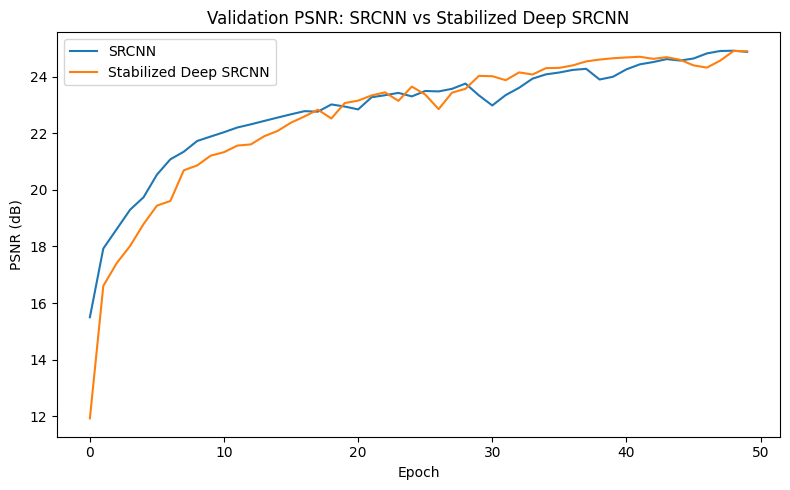

In [23]:

# Plot 2: Validation PSNR — SRCNN vs stabilized Deep SRCNN
plt.figure(figsize=(8, 5))
plt.plot(srcnn_history["val_psnr"], label="SRCNN")
plt.plot(deep_history["val_psnr"], label="Stabilized Deep SRCNN")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Validation PSNR: SRCNN vs Stabilized Deep SRCNN")
plt.legend()
plt.tight_layout()
plt.savefig(
    "/content/outputs/validation_psnr_srcnn_vs_deep.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


### Training behavior

The learning curves let us check whether the models are converging similarly and whether the deeper network benefits from the stabilization changes. The validation PSNR is the main signal used to select the best model checkpoint.

## 12. Deep Residual SRCNN

The residual experiment keeps the **same five-layer convolutional backbone** as Deep SRCNN, but changes what the network learns. Instead of predicting the complete HR image, it predicts a correction that is added to the interpolated input.

`SR = input + F(input)`

The idea is to let the network focus on the missing high-frequency detail while the input already provides much of the coarse image structure.

In [24]:

class DeepResidualSRCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Same five-convolution backbone as Deep SRCNN.
        self.conv1 = nn.Conv2d(3, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 32, kernel_size=1)
        self.conv5 = nn.Conv2d(32, 3, kernel_size=5, padding=2)

        self.relu = nn.ReLU()

    def forward(self, x):
        residual = self.relu(self.conv1(x))
        residual = self.relu(self.conv2(residual))
        residual = self.relu(self.conv3(residual))
        residual = self.relu(self.conv4(residual))
        residual = self.conv5(residual)

        # Global residual learning:
        # final prediction = original input + learned correction
        return x + residual


residual_srcnn = DeepResidualSRCNN().to(device)

residual_params = sum(
    p.numel() for p in residual_srcnn.parameters()
)

print(residual_srcnn)
print(f"\nDeep Residual SRCNN parameters: {residual_params:,}")


DeepResidualSRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv5): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (relu): ReLU()
)

Deep Residual SRCNN parameters: 93,955


In [25]:

# Train Deep Residual SRCNN using the stabilized settings.
RESIDUAL_LR = 3e-4
RESIDUAL_GRAD_CLIP = 1.0

residual_history = train_model(
    residual_srcnn,
    train_loader,
    val_loader,
    lr=RESIDUAL_LR,
    grad_clip_norm=RESIDUAL_GRAD_CLIP
)


Epoch 01/50 | Train Loss: 0.004415 | Val MSE: 0.004263 | Val PSNR: 23.70 dB
Epoch 02/50 | Train Loss: 0.003804 | Val MSE: 0.004183 | Val PSNR: 23.78 dB
Epoch 03/50 | Train Loss: 0.003695 | Val MSE: 0.004031 | Val PSNR: 23.95 dB
Epoch 04/50 | Train Loss: 0.003543 | Val MSE: 0.003871 | Val PSNR: 24.12 dB
Epoch 05/50 | Train Loss: 0.003414 | Val MSE: 0.003723 | Val PSNR: 24.29 dB
Epoch 06/50 | Train Loss: 0.003238 | Val MSE: 0.003525 | Val PSNR: 24.53 dB
Epoch 07/50 | Train Loss: 0.003064 | Val MSE: 0.003360 | Val PSNR: 24.74 dB
Epoch 08/50 | Train Loss: 0.002912 | Val MSE: 0.003194 | Val PSNR: 24.96 dB
Epoch 09/50 | Train Loss: 0.002776 | Val MSE: 0.003083 | Val PSNR: 25.11 dB
Epoch 10/50 | Train Loss: 0.002663 | Val MSE: 0.002949 | Val PSNR: 25.30 dB
Epoch 11/50 | Train Loss: 0.002568 | Val MSE: 0.002859 | Val PSNR: 25.44 dB
Epoch 12/50 | Train Loss: 0.002491 | Val MSE: 0.002784 | Val PSNR: 25.55 dB
Epoch 13/50 | Train Loss: 0.002448 | Val MSE: 0.002733 | Val PSNR: 25.63 dB
Epoch 14/50 

In [26]:

# Evaluate Deep Residual SRCNN.
residual_test_mse, residual_test_psnr = evaluate_model(
    residual_srcnn,
    test_loader
)

print(f"Deep Residual SRCNN Test MSE : {residual_test_mse:.6f}")
print(f"Deep Residual SRCNN Test PSNR: {residual_test_psnr:.2f} dB")

torch.save(
    residual_srcnn.state_dict(),
    "/content/outputs/deep_residual_srcnn.pth"
)


Deep Residual SRCNN Test MSE : 0.001919
Deep Residual SRCNN Test PSNR: 27.17 dB


### Residual-model result

The residual model changes the learning target without changing the five-convolution backbone. Its test score gives us a direct way to assess whether predicting the reconstruction residual is useful in this setting.

In [27]:

# Add the residual model to the main results table.
results.loc[len(results)] = {
    "Method": "Deep Residual SRCNN",
    "Test MSE": residual_test_mse,
    "Test PSNR": residual_test_psnr
}

display(results)


,Method,Test MSE,Test PSNR
0,Nearest Neighbor,0.003608,24.427516
1,Bilinear,0.003663,24.361252
2,Bicubic,0.002985,25.250333
3,SRCNN,0.002848,25.455231
4,Deep SRCNN,0.002894,25.384356
5,U-Net,NaN,NaN
6,Deep Residual SRCNN,0.001919,27.168579


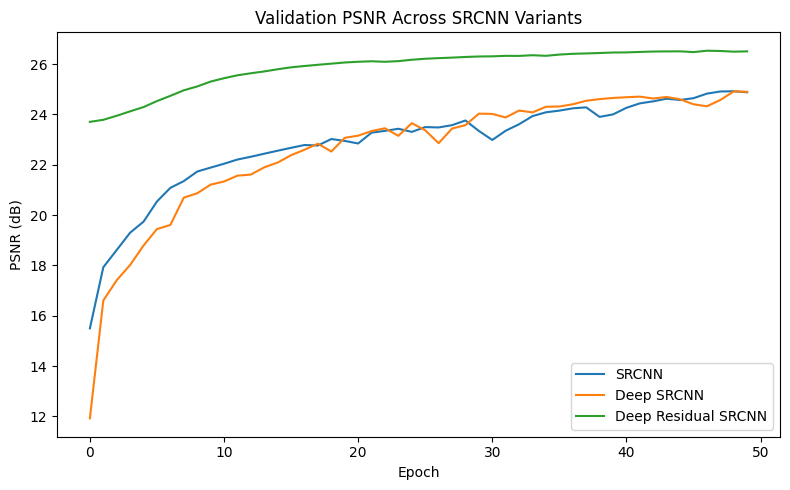

In [28]:

# Plot 3: Validation PSNR across the three neural models.
plt.figure(figsize=(8, 5))
plt.plot(srcnn_history["val_psnr"], label="SRCNN")
plt.plot(deep_history["val_psnr"], label="Deep SRCNN")
plt.plot(residual_history["val_psnr"], label="Deep Residual SRCNN")
plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Validation PSNR Across SRCNN Variants")
plt.legend()
plt.tight_layout()
plt.savefig(
    "/content/outputs/validation_psnr_all_srcnn_variants.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


### Comparing the neural architectures

This plot summarizes the validation PSNR trajectories of the SRCNN variants. It gives a visual view of how the models progress during training rather than relying only on the final test numbers.

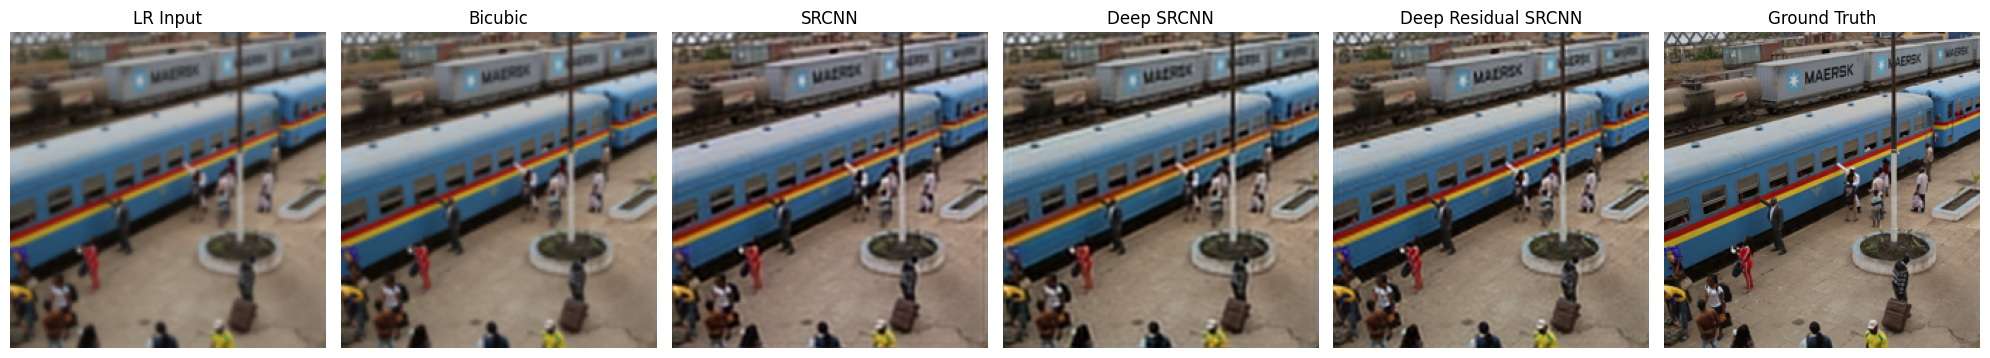

In [29]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_tensor, to_pil_image

# --------------------------------------------------
# Choose one test image
# --------------------------------------------------
idx = test_idx[0]

# Get original image
original = get_image(df.iloc[idx])

# Same preprocessing used throughout the project
hr, lr_small, lr = preprocess_image(original)

# --------------------------------------------------
# Interpolation baseline
# --------------------------------------------------
bicubic = lr_small.resize(
    (IMAGE_SIZE, IMAGE_SIZE),
    Image.Resampling.BICUBIC
)

# --------------------------------------------------
# Prepare model input
# --------------------------------------------------
lr_tensor = to_tensor(lr).unsqueeze(0).to(device)

# --------------------------------------------------
# SRCNN
# --------------------------------------------------
srcnn.eval()

with torch.no_grad():
    srcnn_output = srcnn(lr_tensor).clamp(0, 1)

srcnn_image = to_pil_image(
    srcnn_output.squeeze(0).cpu()
)

# --------------------------------------------------
# Deep SRCNN
# --------------------------------------------------
deep_srcnn.eval()

with torch.no_grad():
    deep_output = deep_srcnn(lr_tensor).clamp(0, 1)

deep_image = to_pil_image(
    deep_output.squeeze(0).cpu()
)

# --------------------------------------------------
# Deep Residual SRCNN
# --------------------------------------------------
residual_srcnn.eval()

with torch.no_grad():
    residual_output = residual_srcnn(lr_tensor).clamp(0, 1)

residual_image = to_pil_image(
    residual_output.squeeze(0).cpu()
)

# --------------------------------------------------
# Plot
# --------------------------------------------------
images = [
    lr,
    bicubic,
    srcnn_image,
    deep_image,
    residual_image,
    hr
]

titles = [
    "LR Input",
    "Bicubic",
    "SRCNN",
    "Deep SRCNN",
    "Deep Residual SRCNN",
    "Ground Truth"
]

plt.figure(figsize=(20, 4))

for i, (image, title) in enumerate(zip(images, titles)):
    plt.subplot(1, 6, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "/content/outputs/final_model_comparison.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Qualitative comparison

The side-by-side reconstructions provide a visual check of the numerical results. In particular, the residual model can be inspected for sharper edges and recovered detail relative to the interpolated input and earlier SRCNN variants.

## 13. Scale the training data

The final experiment increases the training set from the initial 60 images to **800 training images**, with 100 validation images and 100 test images. This tests whether the strongest architecture benefits from substantially more training data while keeping the evaluation protocol fixed.

We also perform a direct **60-image vs. 800-image comparison on the same 100-image test set**, so the data-scaling result is not confounded by a change in the test collection.

In [30]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("NO GPU AVAILABLE")

PyTorch version: 2.11.0+cu130
CUDA build: 13.0
CUDA available: True
GPU count: 1
GPU: Tesla T4


FULL DIV2K EXPERIMENT — OPTIMIZED
Training images : 800
Validation      : 100
Test images     : 100
Batch size      : 4
Epochs          : 50
Learning rate   : 0.0003
Gradient clip   : 1.0
torch.compile   : True

--2026-10-03 07:45:57--  https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip
Resolving data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)... 129.132.52.178, 2001:67c:10ec:36c2::178
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3530603713 (3.3G) [application/zip]
Saving to: ‘/content/DIV2K_train_HR.zip’

/content/DIV2K_trai 100%[===================>]   3.29G  12.4MB/s    in 4m 41s  

2026-10-03 07:50:39 (12.0 MB/s) - ‘/content/DIV2K_train_HR.zip’ saved [3530603713/3530603713]


--2026-10-03 07:50:39--  https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip
Resolving data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)... 129.132.52.178, 2001:67c:10ec:36c2::178
Connecting

Preprocessing TRAIN:   0%|          | 0/800 [00:00<?, ?it/s]

Preprocessing time: 1.46 min
Training cache saved.

Preprocessing 100 validation images...


Preprocessing VALID:   0%|          | 0/100 [00:00<?, ?it/s]

Preprocessing time: 0.19 min
Validation cache saved.

CPU tensor shapes
Train LR: torch.Size([800, 3, 224, 224])
Train HR: torch.Size([800, 3, 224, 224])
Valid LR: torch.Size([100, 3, 224, 224])
Valid HR: torch.Size([100, 3, 224, 224])

Preparing ALL 100 test images...


...

Epoch 49/50:   0%|          | 0/200 [00:00<?, ?batch/s]

Epoch 49/50 | Train MSE: 0.001681 | Val MSE: 0.001680 | Val PSNR: 27.75 dB | 3.5s


Epoch 50/50:   0%|          | 0/200 [00:00<?, ?batch/s]

Epoch 50/50 | Train MSE: 0.001683 | Val MSE: 0.001674 | Val PSNR: 27.76 dB | 3.5s
Epochs completed: 50
Total time: 3.16 minutes
Best validation PSNR: 27.76 dB

Best validation checkpoint restored.
Saved: /content/outputs/deep_residual_srcnn_800.pth

Evaluating on ALL 100 test images...

FINAL 800-IMAGE RESULT
Test MSE : 0.001674
Test PSNR: 27.76 dB

DATA-SCALE COMPARISON
60-image Deep Residual SRCNN : 27.17 dB
800-image Deep Residual SRCNN: 27.76 dB
PSNR change                  : +0.59 dB
60-image MSE                 : 0.001919
800-image MSE                : 0.001674


,Method,Training Images,Test MSE,Test PSNR
0,Nearest Neighbor,-,0.003608,24.427516
1,Bilinear,-,0.003663,24.361252
2,Bicubic,-,0.002985,25.250333
3,SRCNN,60,0.002848,25.455231
4,Deep SRCNN,60,0.002894,25.384356
5,Deep Residual SRCNN,60,0.001919,27.168579
6,Deep Residual SRCNN,800,0.001674,27.762739


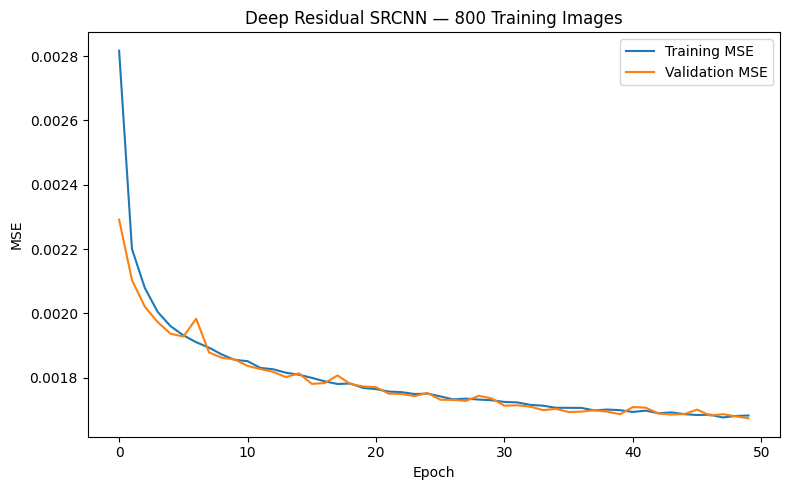

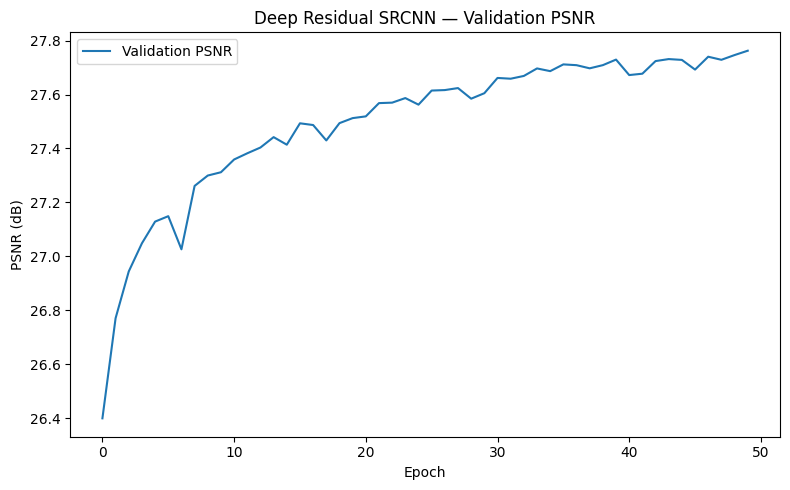

In [31]:
# ============================================================
# FULL DIV2K EXPERIMENT — OPTIMIZED VERSION
# 800 TRAIN / 100 VALIDATION / 100 TEST
# Deep Residual SRCNN
# ============================================================

import os
import glob
import time
import gc
from contextlib import nullcontext

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


# ============================================================
# 1. Configuration
# ============================================================

DIV2K_TRAIN_ZIP = "/content/DIV2K_train_HR.zip"
DIV2K_VALID_ZIP = "/content/DIV2K_valid_HR.zip"

DIV2K_TRAIN_DIR = "/content/DIV2K_train_HR"
DIV2K_VALID_DIR = "/content/DIV2K_valid_HR"

TRAIN_CACHE = "/content/div2k_train_800_cache.pt"
VALID_CACHE = "/content/div2k_valid_100_cache.pt"

NUM_TRAIN = 800
NUM_VALID = 100
NUM_TEST = 100

# ------------------------------------------------------------
# TIMING TEST:
# Run ONE epoch first.
# After checking the runtime, change 1 -> 50 and rerun.
# ------------------------------------------------------------
EPOCHS_FULL = 50

# Larger batch = far fewer GPU launches.
BATCH_SIZE_FULL = 4

# Same stabilized settings as our 60-image
# Deep Residual SRCNN experiment.
FULL_LR = 3e-4
FULL_GRAD_CLIP = 1.0

# torch.compile can improve repeated convolution workloads,
# but if Colab/compiler has trouble, automatically fall back.
USE_COMPILE = True

print("FULL DIV2K EXPERIMENT — OPTIMIZED")
print("=" * 60)
print(f"Training images : {NUM_TRAIN}")
print(f"Validation      : {NUM_VALID}")
print(f"Test images     : {NUM_TEST}")
print(f"Batch size      : {BATCH_SIZE_FULL}")
print(f"Epochs          : {EPOCHS_FULL}")
print(f"Learning rate   : {FULL_LR}")
print(f"Gradient clip   : {FULL_GRAD_CLIP}")
print(f"torch.compile   : {USE_COMPILE}")


# ============================================================
# 2. Download TRAIN set if needed
# ============================================================

if not os.path.exists(DIV2K_TRAIN_ZIP):

    print("\nDownloading DIV2K training HR images...")

    !wget -c --tries=20 --timeout=60 \
    "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_train_HR.zip" \
    -O "$DIV2K_TRAIN_ZIP"

else:

    print("\nTraining zip already exists.")


# ============================================================
# 3. Download VALIDATION set if needed
# ============================================================

if not os.path.exists(DIV2K_VALID_ZIP):

    print("\nDownloading DIV2K validation HR images...")

    !wget -c --tries=20 --timeout=60 \
    "https://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip" \
    -O "$DIV2K_VALID_ZIP"

else:

    print("\nValidation zip already exists.")


# ============================================================
# 4. Extract TRAIN
# ============================================================

train_first_image = os.path.join(
    DIV2K_TRAIN_DIR,
    "0001.png"
)

if not os.path.exists(train_first_image):

    print("\nExtracting training images...")

    !unzip -q -o "$DIV2K_TRAIN_ZIP" -d /content

    print("Training extraction complete.")

else:

    print("\nTraining images already extracted.")


# ============================================================
# 5. Extract VALIDATION
# ============================================================

valid_first_image = os.path.join(
    DIV2K_VALID_DIR,
    "0801.png"
)

if not os.path.exists(valid_first_image):

    print("\nExtracting validation images...")

    !unzip -q -o "$DIV2K_VALID_ZIP" -d /content

    print("Validation extraction complete.")

else:

    print("\nValidation images already extracted.")


# ============================================================
# 6. Verify dataset
# ============================================================

train_paths = sorted(
    glob.glob(
        os.path.join(DIV2K_TRAIN_DIR, "*.png")
    )
)

valid_paths = sorted(
    glob.glob(
        os.path.join(DIV2K_VALID_DIR, "*.png")
    )
)

print("\nDataset verification")
print("-" * 40)

print(
    "Training images found  :",
    len(train_paths)
)

print(
    "Validation images found:",
    len(valid_paths)
)

print(
    "Existing test images   :",
    len(df)
)

assert len(train_paths) == 800
assert len(valid_paths) == 100
assert len(df) == 100

print("Verification passed.")


# ============================================================
# 7. Preprocessing helper
# ============================================================

def preprocess_image_file(path):

    img = Image.open(path).convert("RGB")

    hr, lr_small, lr = preprocess_image(img)

    return (
        to_tensor(hr),
        to_tensor(lr)
    )


# ============================================================
# 8. Load / preprocess TRAIN tensors
# ============================================================

if os.path.exists(TRAIN_CACHE):

    print(
        "\nLoading cached 800-image training tensors..."
    )

    train_cache = torch.load(
        TRAIN_CACHE,
        map_location="cpu"
    )

    train_lr_800 = train_cache["lr"]
    train_hr_800 = train_cache["hr"]

    del train_cache

else:

    print("\nPreprocessing 800 training images...")

    train_lr_list = []
    train_hr_list = []

    start = time.time()

    for path in tqdm(
        train_paths,
        desc="Preprocessing TRAIN"
    ):

        hr_tensor, lr_tensor = (
            preprocess_image_file(path)
        )

        train_hr_list.append(hr_tensor)
        train_lr_list.append(lr_tensor)

    train_hr_800 = torch.stack(
        train_hr_list
    )

    train_lr_800 = torch.stack(
        train_lr_list
    )

    del train_hr_list
    del train_lr_list

    print(
        f"Preprocessing time: "
        f"{(time.time() - start)/60:.2f} min"
    )

    torch.save(
        {
            "lr": train_lr_800,
            "hr": train_hr_800
        },
        TRAIN_CACHE
    )

    print("Training cache saved.")


# ============================================================
# 9. Load / preprocess VALIDATION tensors
# ============================================================

if os.path.exists(VALID_CACHE):

    print(
        "\nLoading cached 100-image validation tensors..."
    )

    valid_cache = torch.load(
        VALID_CACHE,
        map_location="cpu"
    )

    valid_lr_100 = valid_cache["lr"]
    valid_hr_100 = valid_cache["hr"]

    del valid_cache

else:

    print("\nPreprocessing 100 validation images...")

    valid_lr_list = []
    valid_hr_list = []

    start = time.time()

    for path in tqdm(
        valid_paths,
        desc="Preprocessing VALID"
    ):

        hr_tensor, lr_tensor = (
            preprocess_image_file(path)
        )

        valid_hr_list.append(hr_tensor)
        valid_lr_list.append(lr_tensor)

    valid_hr_100 = torch.stack(
        valid_hr_list
    )

    valid_lr_100 = torch.stack(
        valid_lr_list
    )

    del valid_hr_list
    del valid_lr_list

    print(
        f"Preprocessing time: "
        f"{(time.time() - start)/60:.2f} min"
    )

    torch.save(
        {
            "lr": valid_lr_100,
            "hr": valid_hr_100
        },
        VALID_CACHE
    )

    print("Validation cache saved.")


print("\nCPU tensor shapes")

print(
    "Train LR:",
    train_lr_800.shape
)

print(
    "Train HR:",
    train_hr_800.shape
)

print(
    "Valid LR:",
    valid_lr_100.shape
)

print(
    "Valid HR:",
    valid_hr_100.shape
)


# ============================================================
# 10. ALL 100 TEST IMAGES
# ============================================================
# IMPORTANT:
#
# The old `test_idx` contained only 20 images.
# We DO NOT use it here.
#
# `df` contains all 100 images in our existing test collection.

print("\nPreparing ALL 100 test images...")

full_test_lr = []
full_test_hr = []

for i in tqdm(
    range(len(df)),
    desc="Preprocessing TEST"
):

    img = get_image(df.iloc[i])

    hr, lr_small, lr = preprocess_image(img)

    full_test_hr.append(
        to_tensor(hr)
    )

    full_test_lr.append(
        to_tensor(lr)
    )

all_test_hr = torch.stack(
    full_test_hr
)

all_test_lr = torch.stack(
    full_test_lr
)

del full_test_hr
del full_test_lr

print(
    "Test LR:",
    all_test_lr.shape
)

print(
    "Test HR:",
    all_test_hr.shape
)


# ============================================================
# 11. GPU setup
# ============================================================

gc.collect()

if torch.cuda.is_available():

    torch.cuda.empty_cache()

    torch.backends.cudnn.benchmark = True

print("\nGPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Move training + validation data to GPU ONCE.
#
# This eliminates CPU->GPU transfer for every batch.
# These tensors are roughly ~1 GB total for train data,
# which is safe on a 16 GB T4.
# ------------------------------------------------------------

print("\nMoving train/validation tensors to GPU...")

train_lr_gpu = train_lr_800.to(
    device,
    non_blocking=True
)

train_hr_gpu = train_hr_800.to(
    device,
    non_blocking=True
)

valid_lr_gpu = valid_lr_100.to(
    device,
    non_blocking=True
)

valid_hr_gpu = valid_hr_100.to(
    device,
    non_blocking=True
)

print("Train tensors moved to GPU.")
print("Validation tensors moved to GPU.")


# ============================================================
# 12. Create FRESH Deep Residual SRCNN
# ============================================================

full_model = DeepResidualSRCNN().to(device)

# Channels-last can improve convolution throughput on CUDA.
full_model = full_model.to(
    memory_format=torch.channels_last
)

print("\nFresh model created.")

print(
    "Parameters:",
    f"{sum(p.numel() for p in full_model.parameters()):,}"
)


# ============================================================
# 13. Optional torch.compile
# ============================================================

train_model = full_model

if USE_COMPILE:

    print(
        "\nCompiling model..."
    )

    try:

        train_model = torch.compile(
            full_model,
            mode="reduce-overhead"
        )

        print(
            "torch.compile enabled."
        )

    except Exception as e:

        print(
            "torch.compile failed; "
            "continuing normally."
        )

        print(
            "Reason:",
            str(e)
        )

        train_model = full_model


# ============================================================
# 14. Optimizer
# ============================================================

criterion_full = nn.MSELoss()

optimizer_full = torch.optim.Adam(
    full_model.parameters(),
    lr=FULL_LR
)

use_amp = (
    device.type == "cuda"
)

if use_amp:

    scaler_full = torch.amp.GradScaler(
        "cuda"
    )

else:

    scaler_full = None


# ============================================================
# 15. FAST GPU TRAINING
# ============================================================

full_train_losses = []

full_val_mses = []

full_val_psnrs = []

best_full_val_psnr = -float("inf")

best_full_state = None


print("\nStarting FULL DATASET training...")
print("=" * 60)

training_start = time.time()

for epoch in range(EPOCHS_FULL):

    epoch_start = time.time()

    train_model.train()

    # Shuffle indices directly on GPU.
    permutation = torch.randperm(
        NUM_TRAIN,
        device=device
    )

    running_loss = 0.0

    images_seen = 0

    progress = tqdm(
        range(
            0,
            NUM_TRAIN,
            BATCH_SIZE_FULL
        ),
        desc=(
            f"Epoch "
            f"{epoch + 1:02d}/{EPOCHS_FULL}"
        ),
        unit="batch"
    )

    for start_idx in progress:

        batch_idx = permutation[
            start_idx:
            start_idx + BATCH_SIZE_FULL
        ]

        lr_batch = train_lr_gpu[
            batch_idx
        ]

        hr_batch = train_hr_gpu[
            batch_idx
        ]

        # Use channels-last for convolution.
        lr_batch = lr_batch.contiguous(
            memory_format=torch.channels_last
        )

        hr_batch = hr_batch.contiguous(
            memory_format=torch.channels_last
        )

        optimizer_full.zero_grad(
            set_to_none=True
        )

        if use_amp:

            ctx = torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            )

        else:

            ctx = nullcontext()

        with ctx:

            output = train_model(
                lr_batch
            )

            loss = criterion_full(
                output,
                hr_batch
            )

        # ----------------------------------------------------
        # BACKPROP
        # ----------------------------------------------------

        if use_amp:

            scaler_full.scale(
                loss
            ).backward()

            # Unscale before clipping.
            scaler_full.unscale_(
                optimizer_full
            )

            torch.nn.utils.clip_grad_norm_(
                full_model.parameters(),
                max_norm=FULL_GRAD_CLIP
            )

            scaler_full.step(
                optimizer_full
            )

            scaler_full.update()

        else:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                full_model.parameters(),
                max_norm=FULL_GRAD_CLIP
            )

            optimizer_full.step()

        bs = lr_batch.size(0)

        running_loss += (
            loss.item() * bs
        )

        images_seen += bs

        progress.set_postfix(
            loss=f"{loss.item():.5f}"
        )


    # --------------------------------------------------------
    # TRAINING MSE
    # --------------------------------------------------------

    train_loss = (
        running_loss /
        images_seen
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    full_model.eval()

    validation_error = 0.0

    validation_pixels = 0

    with torch.inference_mode():

        for start_idx in range(
            0,
            NUM_VALID,
            BATCH_SIZE_FULL
        ):

            end_idx = min(
                start_idx + BATCH_SIZE_FULL,
                NUM_VALID
            )

            lr_batch = valid_lr_gpu[
                start_idx:end_idx
            ]

            hr_batch = valid_hr_gpu[
                start_idx:end_idx
            ]

            lr_batch = lr_batch.contiguous(
                memory_format=torch.channels_last
            )

            hr_batch = hr_batch.contiguous(
                memory_format=torch.channels_last
            )

            output = full_model(
                lr_batch
            ).clamp(0, 1)

            validation_error += torch.sum(
                (output - hr_batch) ** 2
            ).item()

            validation_pixels += (
                hr_batch.numel()
            )


    val_mse = (
        validation_error /
        validation_pixels
    )

    val_psnr = calculate_psnr_from_mse(
        val_mse
    )


    full_train_losses.append(
        train_loss
    )

    full_val_mses.append(
        val_mse
    )

    full_val_psnrs.append(
        val_psnr
    )


    # --------------------------------------------------------
    # BEST CHECKPOINT
    # --------------------------------------------------------

    if val_psnr > best_full_val_psnr:

        best_full_val_psnr = val_psnr

        best_full_state = {
            k: v.detach().cpu().clone()
            for k, v in full_model.state_dict().items()
        }


    epoch_time = (
        time.time() -
        epoch_start
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS_FULL} | "
        f"Train MSE: {train_loss:.6f} | "
        f"Val MSE: {val_mse:.6f} | "
        f"Val PSNR: {val_psnr:.2f} dB | "
        f"{epoch_time:.1f}s"
    )


total_time = (
    time.time() -
    training_start
)

print("=" * 60)

print(
    f"Epochs completed: {EPOCHS_FULL}"
)

print(
    f"Total time: "
    f"{total_time / 60:.2f} minutes"
)

print(
    f"Best validation PSNR: "
    f"{best_full_val_psnr:.2f} dB"
)


# ============================================================
# 16. Restore BEST model
# ============================================================

full_model.load_state_dict(
    best_full_state
)

full_model.to(device)

print(
    "\nBest validation checkpoint restored."
)


# ============================================================
# 17. Save model
# ============================================================

os.makedirs(
    "/content/outputs",
    exist_ok=True
)

FULL_MODEL_PATH = (
    "/content/outputs/"
    "deep_residual_srcnn_800.pth"
)

torch.save(
    full_model.state_dict(),
    FULL_MODEL_PATH
)

print(
    "Saved:",
    FULL_MODEL_PATH
)


# ============================================================
# 18. FINAL TEST — ALL 100 IMAGES
# ============================================================

print(
    "\nEvaluating on ALL 100 test images..."
)

full_test_dataset = TensorDataset(
    all_test_lr,
    all_test_hr
)

full_test_loader = DataLoader(
    full_test_dataset,
    batch_size=64,
    shuffle=False,
    pin_memory=torch.cuda.is_available()
)

full_test_mse, full_test_psnr = evaluate_model(
    full_model,
    full_test_loader
)

print("\n" + "=" * 60)
print("FINAL 800-IMAGE RESULT")
print("=" * 60)

print(
    f"Test MSE : {full_test_mse:.6f}"
)

print(
    f"Test PSNR: {full_test_psnr:.2f} dB"
)


# ============================================================
# 19. DATA-SCALE COMPARISON
# ============================================================

print("\n" + "=" * 60)
print("DATA-SCALE COMPARISON")
print("=" * 60)

print(
    f"60-image Deep Residual SRCNN : "
    f"{residual_test_psnr:.2f} dB"
)

print(
    f"800-image Deep Residual SRCNN: "
    f"{full_test_psnr:.2f} dB"
)

print(
    f"PSNR change                  : "
    f"{full_test_psnr - residual_test_psnr:+.2f} dB"
)

print(
    f"60-image MSE                 : "
    f"{residual_test_mse:.6f}"
)

print(
    f"800-image MSE                : "
    f"{full_test_mse:.6f}"
)


# ============================================================
# 20. Final results table
# ============================================================

final_results = pd.DataFrame([
    {
        "Method": "Nearest Neighbor",
        "Training Images": "-",
        "Test MSE": baseline_results["nearest"]["MSE"],
        "Test PSNR": baseline_results["nearest"]["PSNR"]
    },

    {
        "Method": "Bilinear",
        "Training Images": "-",
        "Test MSE": baseline_results["bilinear"]["MSE"],
        "Test PSNR": baseline_results["bilinear"]["PSNR"]
    },

    {
        "Method": "Bicubic",
        "Training Images": "-",
        "Test MSE": baseline_results["bicubic"]["MSE"],
        "Test PSNR": baseline_results["bicubic"]["PSNR"]
    },

    {
        "Method": "SRCNN",
        "Training Images": 60,
        "Test MSE": srcnn_test_mse,
        "Test PSNR": srcnn_test_psnr
    },

    {
        "Method": "Deep SRCNN",
        "Training Images": 60,
        "Test MSE": deep_test_mse,
        "Test PSNR": deep_test_psnr
    },

    {
        "Method": "Deep Residual SRCNN",
        "Training Images": 60,
        "Test MSE": residual_test_mse,
        "Test PSNR": residual_test_psnr
    },

    {
        "Method": "Deep Residual SRCNN",
        "Training Images": 800,
        "Test MSE": full_test_mse,
        "Test PSNR": full_test_psnr
    }
])

display(final_results)


# ============================================================
# 21. Loss curve
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    full_train_losses,
    label="Training MSE"
)

plt.plot(
    full_val_mses,
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title(
    "Deep Residual SRCNN — 800 Training Images"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/outputs/"
    "deep_residual_800_loss.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 22. Validation PSNR
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    full_val_psnrs,
    label="Validation PSNR"
)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title(
    "Deep Residual SRCNN — Validation PSNR"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "/content/outputs/"
    "deep_residual_800_val_psnr.png",
    dpi=250,
    bbox_inches="tight"
)

plt.show()

### Full-data training result

The larger experiment trains the Deep Residual SRCNN using 800 training images and then evaluates the resulting checkpoint on the full 100-image test collection. The training curves also show how the model behaves when substantially more training data is available.

In [32]:
# Evaluate the already-trained 60-image Deep Residual SRCNN
# on the SAME 100 test images used for the 800-image model.

same_test_dataset = TensorDataset(
    all_test_lr,
    all_test_hr
)

same_test_loader = DataLoader(
    same_test_dataset,
    batch_size=64,
    shuffle=False
)

residual_60_mse_fair, residual_60_psnr_fair = evaluate_model(
    residual_srcnn,
    same_test_loader
)

print("=" * 60)
print("FAIR DATA-SCALE COMPARISON")
print("=" * 60)

print(
    f"60-image model : "
    f"MSE = {residual_60_mse_fair:.6f}, "
    f"PSNR = {residual_60_psnr_fair:.2f} dB"
)

print(
    f"800-image model: "
    f"MSE = {full_test_mse:.6f}, "
    f"PSNR = {full_test_psnr:.2f} dB"
)

print(
    f"\nPSNR difference: "
    f"{full_test_psnr - residual_60_psnr_fair:+.2f} dB"
)

FAIR DATA-SCALE COMPARISON
60-image model : MSE = 0.001993, PSNR = 27.00 dB
800-image model: MSE = 0.001674, PSNR = 27.76 dB

PSNR difference: +0.76 dB


### Controlled data-scale comparison

The final comparison evaluates both residual models on the **same 100 test images**. This isolates the effect of increasing the training set from 60 to 800 images and gives the cleanest evidence for the data-scaling experiment.

---

# References and Acknowledgements

### References

1. Garber, B., Grossman, A., & Johnson-Yu, S.  
   *Image Super-Resolution Via a Convolutional Neural Network.*  
   Stanford CS229 Machine Learning Project, 2020.  
   [Project Paper](https://cs229.stanford.edu/proj2020spr/report/Garber_Grossman_Johnson-Yu.pdf)

2. Dong, C., Loy, C. C., He, K., & Tang, X.  
   *Image Super-Resolution Using Deep Convolutional Networks.*  
   IEEE Transactions on Pattern Analysis and Machine Intelligence, 38(2), 295–307, 2016.  
   [arXiv:1501.00092](https://arxiv.org/abs/1501.00092)

3. Agustsson, E., & Timofte, R.  
   *NTIRE 2017 Challenge on Single Image Super-Resolution: Dataset and Study.*  
   Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition Workshops, 2017.  
   [CVPR Workshops](https://openaccess.thecvf.com/)

4. DIV2K Dataset  
   Agustsson, E., & Timofte, R.  
   *NTIRE 2017 Challenge on Single Image Super-Resolution: Dataset and Study.*  
   The dataset was used as the source of the high-resolution training and validation images in this project.  
   [DIV2K Dataset](https://data.vision.ee.ethz.ch/cvl/DIV2K/)

5. PyTorch Documentation  
   The implementation uses PyTorch for model definition, training, tensor operations, and evaluation.  
   [PyTorch](https://pytorch.org/docs/)

6. Pillow Documentation  
   Used for image loading and preprocessing operations.  
   [Pillow](https://pillow.readthedocs.io/)

### Acknowledgements

We thank the authors of the above works for making their research and resources publicly available. The original Stanford CS229 project served as the primary reference for the experimental setup, preprocessing pipeline, and baseline comparisons, while the SRCNN architecture is based on the work of Dong et al.

### Reproducibility

All experiments in this notebook use the same preprocessing pipeline and evaluation procedure unless explicitly stated otherwise. Random seeds, dataset splits, model configurations, and evaluation metrics are kept consistent wherever applicable to make comparisons between experiments meaningful.